# Admixture dating: cross-ancestry rate through time

A **separate, optional deliverable** from painting. Making the ancestry CTMC
*time-inhomogeneous* and fitting the cross-ancestry transition rate as a function of (backward)
time gives a profile `q_AB(t)`, `q_BA(t)` that locates **when** the two labelled ancestries
diverged or exchanged genes — directionally. It rides the same EM engine
([`fit_rate_through_time`](../api/fit_rate_through_time.html)) and can reuse a `paint` fit via
`Painting.rate_through_time()`, leaving the painting itself untouched.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import tspaint
from tspaint.sim import SOURCE_A, SOURCE_B, ADMIXED

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

def admixture(n_admix=8, n_ref=8, L=2e6, T_admix=100, Ne=1000, T_split=5000, f_A=0.5,
              seed=1, infer=False, mutation_rate=4e-7):
    """Simulate admixture with known truth; return (ts, labels, queries, truth_states)."""
    ts = tspaint.simulate_admixture(n_admix=n_admix, n_ref=n_ref, sequence_length=L,
                                  recombination_rate=1e-8, random_seed=seed, Ne=Ne,
                                  T_admix=T_admix, T_split=T_split, f_A=f_A)
    pop = ts.tables.nodes.population
    name = {p: ts.population(p).metadata.get("name", str(p)) for p in range(ts.num_populations)}
    A = next(p for p, n in name.items() if n == SOURCE_A)
    B = next(p for p, n in name.items() if n == SOURCE_B)
    admix = next(p for p, n in name.items() if n == ADMIXED)
    sop = {A: 0, B: 1}
    labels = {int(s): sop[pop[s]] for s in ts.samples() if pop[s] in (A, B)}
    queries = [int(s) for s in ts.samples() if pop[s] == admix]
    truth = tspaint.metrics.map_truth({q: tspaint.local_ancestry_truth(ts)[0][q] for q in queries}, sop)
    work = ts
    if infer:
        work = tspaint.io.infer_tree_sequence(tspaint.io.add_mutations(ts, rate=mutation_rate,
                                                                   random_seed=seed))
    return work, labels, queries, truth

CMAP = "RdBu_r"   # red = ancestry A (state 0), blue = ancestry B (state 1)

def plot_painting(painting, truth, ts, title="", segments=None):
    """Soft posterior P(A) painted along the genome per query haplotype, with a thin truth
    strip beneath each. If `segments` (hard tracts) is given, draw those instead of soft."""
    qs = painting.queries
    L = ts.sequence_length
    sm = cm.ScalarMappable(norm=colors.Normalize(0, 1), cmap=CMAP)
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(qs) + 1.2))
    for i, q in enumerate(qs):
        if segments is None:
            for seg in painting.posteriors[q]:
                ax.barh(i, seg.right - seg.left, left=seg.left, height=0.74,
                        color=sm.to_rgba(seg.posterior[0]), edgecolor="none")
        else:
            for (l, r, s) in segments[q]:
                ax.barh(i, r - l, left=l, height=0.74,
                        color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
        for (l, r, s) in truth[q]:
            ax.barh(i - 0.46, r - l, left=l, height=0.13,
                    color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
    ax.set_xlim(0, L); ax.set_ylim(-0.8, len(qs) - 0.2)
    ax.set_yticks(range(len(qs))); ax.set_yticklabels([f"hap {q}" for q in qs], fontsize=8)
    ax.set_xlabel("genomic position (bp)"); ax.set_title(title)
    cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cb.set_label("P(ancestry A)")
    ax.text(0, len(qs) - 0.5, "thin strip below each = true ancestry", fontsize=7, color="0.4")
    fig.tight_layout()
    return fig

## Paint, then date — reusing the fit

A clean split at `T_split`: the cross-ancestry rate must be ~0 more recently than the split (the two ancestries cannot share ancestry yet) and rise once `t` exceeds it. `Painting.rate_through_time()` warm-starts from the painting's fitted `(Q, π, w)` and returns a **new** profile — `painting.posteriors` is not modified.

In [3]:
T_split = 3000
ts, labels, queries, truth = admixture(n_admix=6, n_ref=8, L=5e5, T_admix=200, T_split=T_split,
                                       Ne=1000, seed=1)
painting = tspaint.paint(ts, labels)
rtt = painting.rate_through_time(n_iter=10)     # reuses the painting's fit; posteriors untouched
rtt

RateThroughTime(centers=array([  12.66799536,   15.02422958,   17.81872097,   21.1329849 ,
         25.06369855,   29.72552093,   35.25443752,   41.81172697,
         49.58866556,   58.8121068 ,   69.75109871,   82.72473197,
         98.11144778,  116.36007705,  138.00293277,  163.67133758,
        194.11403952,  230.21905299,  273.03956216,  323.82464238,
        384.05569575,  455.48966365,  540.21027676,  640.68883754,
        759.8563082 ,  901.18880692, 1068.80900632, 1267.60639195,
       1503.37988864, 1783.00701536, 2114.6445026 , 2507.9662244 ,
       2974.44538549, 3527.689195  , 4183.83578911, 4962.02498084,
       5884.95656893, 6979.55249157, 8277.74213997, 9817.39373959]), q_AB=array([1.00000000e-09, 1.00000000e-09, 1.00000000e-09, 1.00000000e-09,
       1.00000000e-09, 1.00000000e-09, 1.00000000e-09, 1.00000000e-09,
       1.00000000e-09, 1.00000000e-09, 1.00000000e-09, 1.00000000e-09,
       1.00000000e-09, 1.00000000e-09, 1.00000000e-09, 1.00000000e-09,
       1.000000

## The profile

`q_AB(t)` and `q_BA(t)` vs (backward) time on a log axis. The rise marks the divergence epoch; recent time carries ~no cross-ancestry rate. (Convention: a jump is parent→child = old→young = forward in time, so a *backward*-time A→B admixture shows in `q_BA`.)

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_98776/1392532580.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


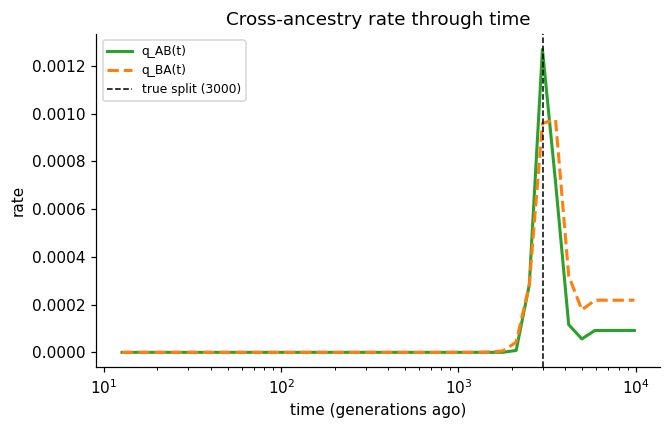

In [4]:
#| label: fig-dating-profile
#| fig-cap: "Directional cross-ancestry transition rates q_AB(t), q_BA(t) vs backward time: ~0 more recent than the population split, rising once cross-ancestry sharing becomes possible. The dashed line is the true split time."
fig, ax = plt.subplots(figsize=(6.2, 4))
rtt.plot(ax=ax)
ax.axvline(T_split, color="k", ls="--", lw=1, label=f"true split ({T_split})")
ax.set_title("Cross-ancestry rate through time"); ax.legend(fontsize=8); fig.tight_layout()
fig.show()

## Reading off the onset

The standalone entry point `tspaint.fit_rate_through_time(ts, labels)` does the same fit without a painting.

In [4]:
import numpy as np
onset = rtt.centers[np.argmax(rtt.q_AB > 0.5 * np.nanmax(rtt.q_AB))]
print(f"inferred onset ~ {onset:.0f} generations   (true split {T_split})")

inferred onset ~ 2974 generations   (true split 3000)
